# **TS2: Modelizando un ADC**

El ADC trabaja con una frecuencia de muestreo:

$$
f_s = 1000\text{ Hz}
$$

y un rango analógico:

$$
\pm V_F = \pm 2\text{ V}
$$

Se analizará una señal senoidal de energía normalizada, contaminada con ruido gaussiano aditivo, y posteriormente cuantizada por un ADC de $B$ bits.

Se estudiará inicialmente el caso:

$$
B=4,\qquad k_n=1
$$

y luego se analizarán diferentes combinaciones de cantidad de bits y nivel de ruido.


## 1. Generación de la señal senoidal

La señal de entrada se considera senoidal, con frecuencia:

$$
f_0 = \frac{f_s}{N}
$$

Para $f_s=1000$ Hz y $N=1000$ muestras:

$$
f_0 = \frac{1000}{1000}=1\text{ Hz}
$$

De esta manera, se obtiene un período completo de la señal dentro del intervalo de observación.

La señal se genera como:

$$
s(t)=V_{max}\sin(2\pi f_0t+\phi)
$$

Se desea que la señal tenga energía (o potencia media, para una señal de media nula) unitaria. Para una senoidal:

$$
P=\frac{V_{max}^2}{2}
$$

Por lo tanto, tomando:

$$
V_{max}=\sqrt{2}\text{ V}
$$

se obtiene:

$$
P=1\text{ W}
$$

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

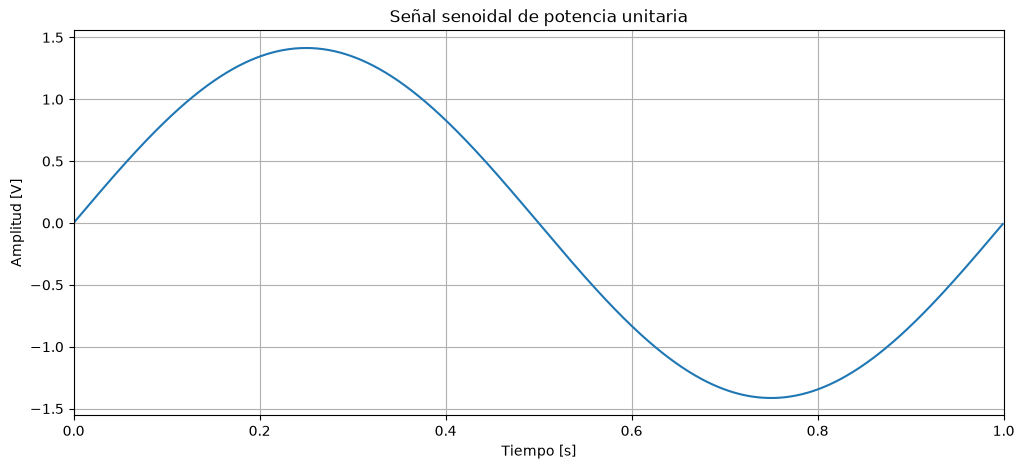

In [20]:
fs = 1000
N = 1000
VF = 2
B = 4
kn = 1

def mi_funcion_sen(vmax, dc, ff, ph, nn=N, fs=fs):
    tt = np.arange(nn) / fs
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx


f0 = fs / N
vmax = np.sqrt(2)
dc = 0
ph = 0

tt, s = mi_funcion_sen(
    vmax=vmax,
    dc=dc,
    ff=f0,
    ph=ph
)

plt.figure(figsize=(12, 5))

plt.plot(tt, s)

plt.title("Señal senoidal de potencia unitaria")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")

plt.grid()

plt.xlim(0, 1)

plt.show()

# 2. Caso a: ADC de 4 bits y $k_n=1$

Para el primer caso se considera:

$$
B=4
$$

$$
k_n=1
$$

$$
V_F=2\text{ V}
$$

La resolución del ADC, según la convención utilizada en esta consigna, se calcula como:

$$
q=\frac{V_F}{2^B}
$$

Por lo tanto:

$$
q=\frac{2}{2^4}
=\frac{2}{16}
=0.125\text{ V}
$$

La potencia del ruido de cuantización se considera:

$$
P_q=\frac{q^2}{12}
$$

y la potencia del ruido agregado a la señal es:

$$
P_n=k_nP_q
$$

Para $k_n=1$:

$$
P_n=P_q
$$

El ruido se modela como un proceso gaussiano de media cero:

$$
n\sim\mathcal{N}(0,\sigma_n^2)
$$

donde:

$$
\sigma_n=\sqrt{P_n}
$$

La señal que ingresa al ADC es:

$$
s_R=s+n
$$

In [21]:
def ruido_adc(B, kn, VF, nn=N):
    q = VF / (2**B)
    Pq = q**2 / 12
    Pn = kn * Pq
    sigma = np.sqrt(Pn)
    n = np.random.normal(loc=0,scale=sigma,size=nn)
    return n, q, Pq, Pn

n, q, Pq, Pn = ruido_adc(B=B,kn=kn,VF=VF)

sR = s + n

## 2.2 Cuantización

La señal con ruido es cuantizada mediante un ADC de $B$ bits.

El paso de cuantización es:

$$
q=\frac{V_F}{2^B}
$$

La cuantización se realiza redondeando cada muestra al nivel de cuantización más cercano:

$$
s_Q=q\cdot\operatorname{round}\left(\frac{s_R}{q}\right)
$$

La salida $s_Q$ representa la señal digitalizada por el ADC.

El error de cuantización se define como:

$$
e_Q=s_Q-s_R
$$

In [22]:
def cuantizar(x, B, VF):
    q = VF / (2**B)
    x_sat = np.clip(x, -VF, VF)
    xq = np.round(x_sat / q) * q
    return xq

sq = cuantizar(sR, B, VF)

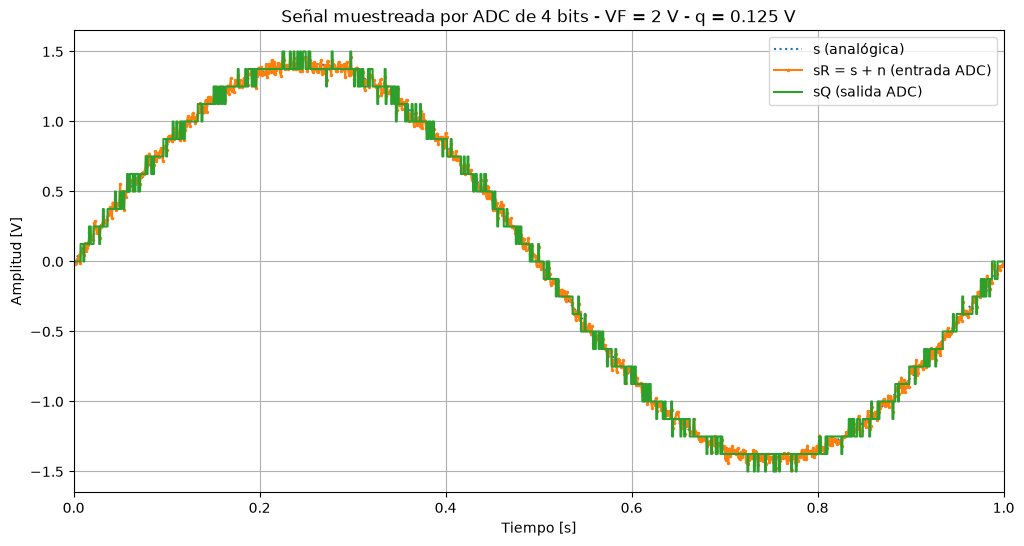

In [23]:
plt.figure(figsize=(12, 6))

plt.plot(tt, s, label="s (analógica)", linestyle=":")
plt.plot(tt, sR, label="sR = s + n (entrada ADC)", marker=".", markersize=3)
plt.step(tt, sq, where="mid", label="sQ (salida ADC)")
plt.title(f"Señal muestreada por ADC de {B} bits - "f"VF = {VF} V - q = {q:.3f} V")

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")

plt.grid()
plt.legend()
plt.xlim(0, 1)
plt.show()

## 2.3 Ruido de cuantización

El error introducido por el proceso de cuantización se calcula como:

$$
e_Q=s_Q-s_R
$$

La potencia del ruido de cuantización se obtiene a partir de la varianza o del valor cuadrático medio del error:

$$
P_{Q,medida}=\frac{1}{N}\sum_{n=0}^{N-1}e_Q^2[n]
$$

Este valor puede expresarse en decibeles como:

$$
P_{Q,dB}=10\log_{10}(P_{Q,medida})
$$

También se dispone del valor teórico:

$$
P_q=\frac{q^2}{12}
$$

Para $B=4$ y $q=0.125$ V:

$$
P_q=\frac{(0.125)^2}{12}
\approx1.302\times10^{-3}\text{ W}
$$

El valor medido puede presentar pequeñas diferencias respecto del valor teórico debido a la cantidad finita de muestras y a la realización aleatoria del ruido.

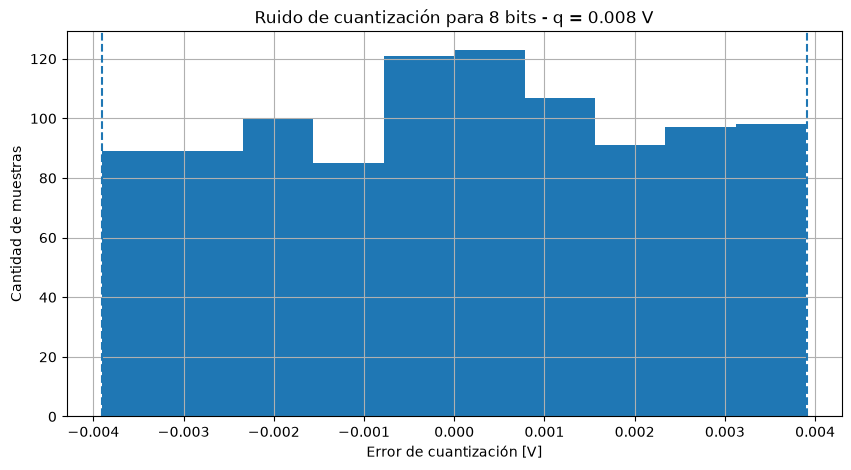

In [30]:
eq = sq - sR

Pq_medida = np.mean(eq**2)

plt.figure(figsize=(10, 5))
plt.hist(eq, bins=10)
plt.axvline(-q/2, linestyle="--")
plt.axvline(q/2, linestyle="--")

plt.title(f"Ruido de cuantización para {B} bits - "f"q = {q:.3f} V")

plt.xlabel("Error de cuantización [V]")
plt.ylabel("Cantidad de muestras")
plt.grid()
plt.show()

## 2.3 Densidad espectral de potencia

Para analizar las señales en el dominio de la frecuencia se calcula la densidad espectral de potencia mediante la Transformada de Fourier.

Se analizan:

- $s$: señal original.
- $s_R=s+n$: señal con ruido a la entrada del ADC.
- $s_Q$: señal cuantizada a la salida del ADC.

A partir de la Transformada de Fourier $X[k]$, se calcula la densidad de potencia como:

$$
PSD(f)=\frac{|X(f)|^2}{Nf_s}
$$

La densidad de potencia se expresa en decibeles mediante:

$$
PSD_{dB}(f)=10\log_{10}(PSD(f))
$$

Debido a que la frecuencia de muestreo es:

$$
f_s=1000\text{ Hz}
$$

el análisis se realiza hasta la frecuencia de Nyquist:

$$
f_N=\frac{f_s}{2}=500\text{ Hz}
$$

La componente correspondiente a la señal senoidal se encuentra en $f_0=1$ Hz, mientras que el ruido se distribuye sobre el espectro.

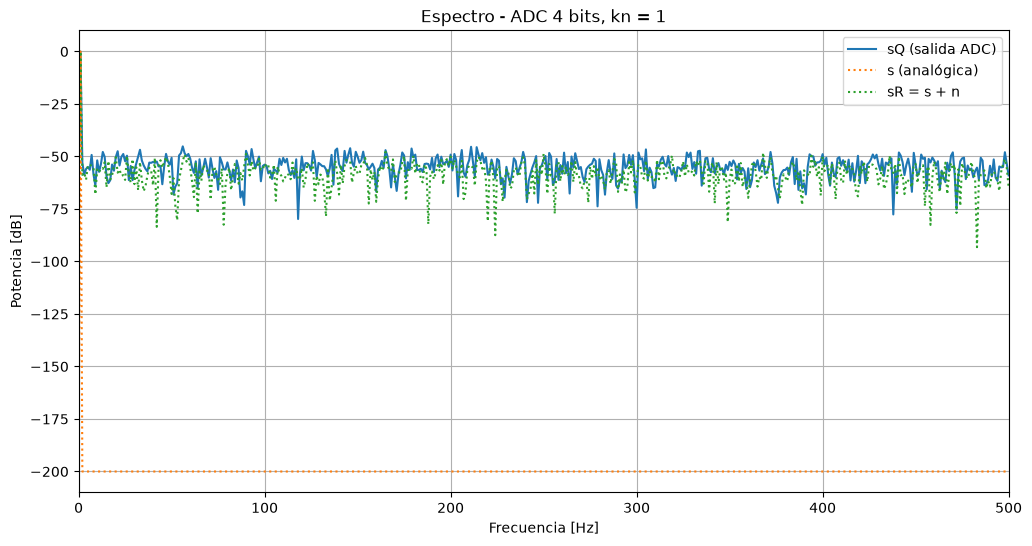

In [25]:
def espectro(x, fs):
    N = len(x)
    X = np.fft.rfft(x)
    P = np.abs(X)**2 / N**2
    P[1:-1] *= 2
    f = np.fft.rfftfreq(N, 1/fs)
    PdB = 10 * np.log10(P + 1e-20)
    return f, PdB

f, S_dB = espectro(s, fs)
_, SR_dB = espectro(sR, fs)
_, SQ_dB = espectro(sq, fs)

plt.figure(figsize=(12, 6))

plt.plot(f, SQ_dB, label="sQ (salida ADC)")
plt.plot(f, S_dB, linestyle=":", label="s (analógica)")
plt.plot(f, SR_dB, linestyle=":", label="sR = s + n")
plt.title(f"Espectro - ADC {B} bits, kn = {kn}")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [dB]")
plt.grid()
plt.legend()
plt.xlim(0, fs/2)
plt.show()

# 3. Análisis para diferentes valores de B y kn

En esta segunda parte se estudia el comportamiento del ADC modificando:

$$
B=\{4,8,16\}
$$

y

$$
k_n=\left\{\frac{1}{10},1,10\right\}
$$

Se mantienen constantes:

$$
f_s=1000\text{ Hz}
$$

$$
V_F=2\text{ V}
$$

$$
f_0=1\text{ Hz}
$$

y la potencia de la señal:

$$
P_s=1\text{ W}
$$

Para cada cantidad de bits, el paso de cuantización es:

$$
q=\frac{V_F}{2^B}
$$

Por lo tanto:

| Bits | $q$ [V] |
|------|---------|
| 4 | 0.125 |
| 8 | 0.0078125 |
| 16 | 0.0000305176 |

Al aumentar la cantidad de bits, disminuye el paso de cuantización y, por lo tanto, disminuye la potencia del ruido de cuantización:

$$
P_q=\frac{q^2}{12}
$$

Por otro lado, el ruido agregado a la señal depende de $k_n$:

$$
P_n=k_nP_q
$$

Por lo tanto, para una misma cantidad de bits, aumentar $k_n$ implica aumentar la potencia del ruido presente en la entrada del ADC.

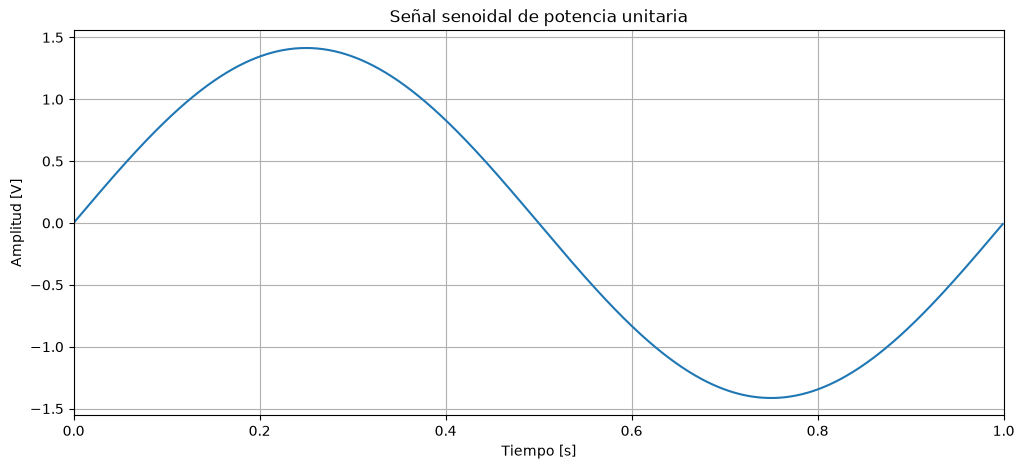

In [31]:
# Caso B=8 kn=1

fs = 1000
N = 1000
VF = 2
B = 8
kn = 1

def mi_funcion_sen(vmax, dc, ff, ph, nn=N, fs=fs):
    tt = np.arange(nn) / fs
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx


f0 = fs / N
vmax = np.sqrt(2)
dc = 0
ph = 0

tt, s = mi_funcion_sen(
    vmax=vmax,
    dc=dc,
    ff=f0,
    ph=ph
)

plt.figure(figsize=(12, 5))

plt.plot(tt, s)

plt.title("Señal senoidal de potencia unitaria")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")

plt.grid()

plt.xlim(0, 1)

plt.show()

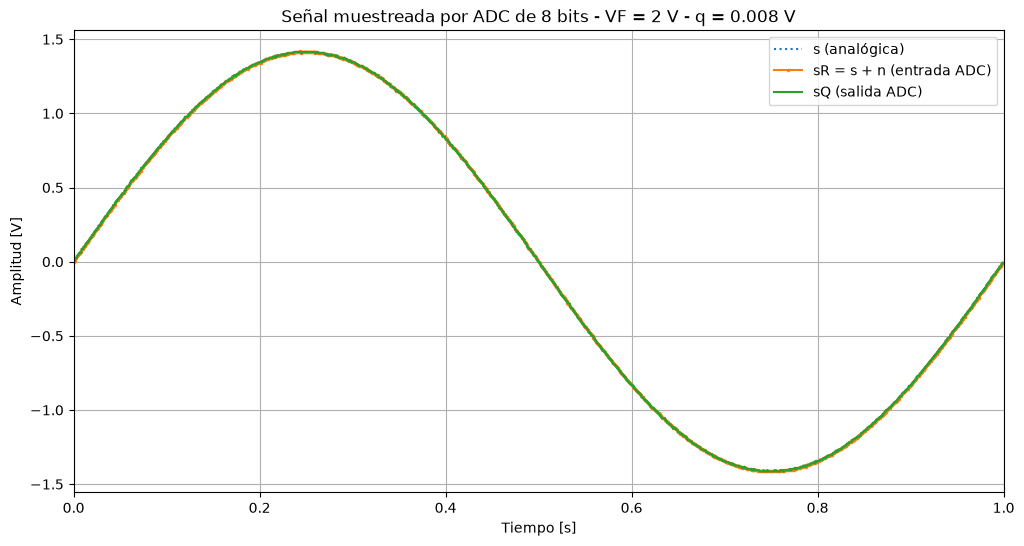

In [27]:
def ruido_adc(B, kn, VF, nn=N):
    q = VF / (2**B)
    Pq = q**2 / 12
    Pn = kn * Pq
    sigma = np.sqrt(Pn)
    n = np.random.normal(loc=0,scale=sigma,size=nn)
    return n, q, Pq, Pn

n, q, Pq, Pn = ruido_adc(B=B,kn=kn,VF=VF)

sR = s + n

def cuantizar(x, B, VF):
    q = VF / (2**B)
    x_sat = np.clip(x, -VF, VF)
    xq = np.round(x_sat / q) * q
    return xq

sq = cuantizar(sR, B, VF)

plt.figure(figsize=(12, 6))

plt.plot(tt, s, label="s (analógica)", linestyle=":")
plt.plot(tt, sR, label="sR = s + n (entrada ADC)", marker=".", markersize=3)
plt.step(tt, sq, where="mid", label="sQ (salida ADC)")
plt.title(f"Señal muestreada por ADC de {B} bits - "f"VF = {VF} V - q = {q:.3f} V")

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")

plt.grid()
plt.legend()
plt.xlim(0, 1)
plt.show()

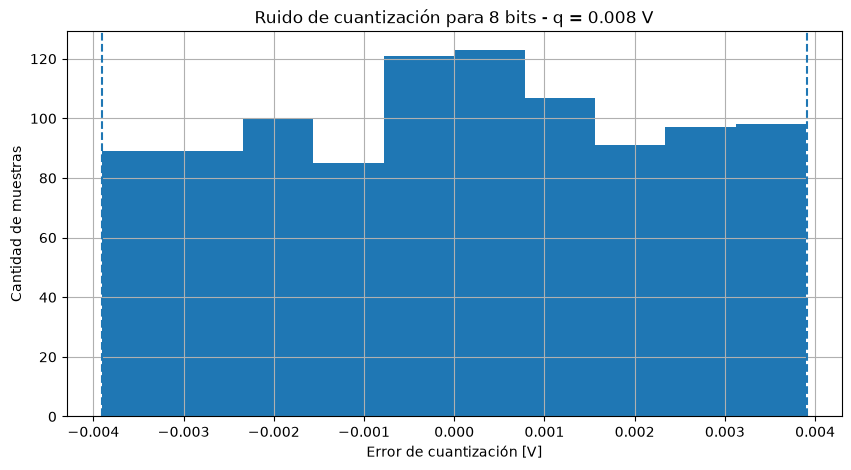

In [28]:
eq = sq - sR

Pq_medida = np.mean(eq**2)

plt.figure(figsize=(10, 5))
plt.hist(eq, bins=10)
plt.axvline(-q/2, linestyle="--")
plt.axvline(q/2, linestyle="--")

plt.title(f"Ruido de cuantización para {B} bits - "f"q = {q:.3f} V")

plt.xlabel("Error de cuantización [V]")
plt.ylabel("Cantidad de muestras")
plt.grid()
plt.show()

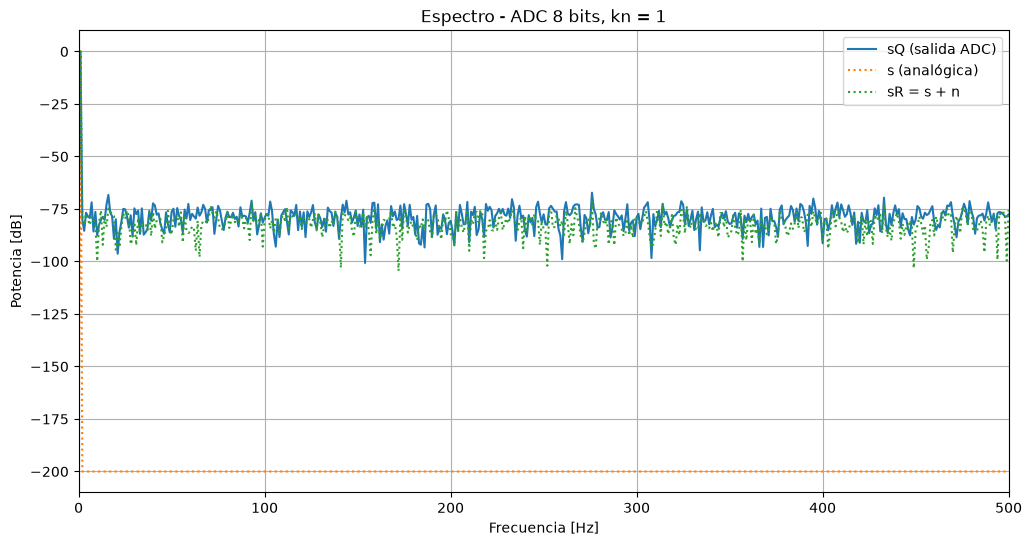

In [29]:
def espectro(x, fs):
    N = len(x)
    X = np.fft.rfft(x)
    P = np.abs(X)**2 / N**2
    P[1:-1] *= 2
    f = np.fft.rfftfreq(N, 1/fs)
    PdB = 10 * np.log10(P + 1e-20)
    return f, PdB

f, S_dB = espectro(s, fs)
_, SR_dB = espectro(sR, fs)
_, SQ_dB = espectro(sq, fs)

plt.figure(figsize=(12, 6))

plt.plot(f, SQ_dB, label="sQ (salida ADC)")
plt.plot(f, S_dB, linestyle=":", label="s (analógica)")
plt.plot(f, SR_dB, linestyle=":", label="sR = s + n")
plt.title(f"Espectro - ADC {B} bits, kn = {kn}")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [dB]")
plt.grid()
plt.legend()
plt.xlim(0, fs/2)
plt.show()